# **EE214 Assignment 3**

In this assignment, you should use a GPU provided by Colab. Please set the hardware accelerator to GPU. And in Colab, there is a GPU usage limit of up to 12 hours per day. So it is recommended to do this assignment in advance when you have enough time.



# **Part 1.** Implement LSTM model in word-level language modelling

## **Task** : **IMDB Movie Review Sentiment Analysis**
- This task takes a movie review (text data) as input and classifies it as 1 for positive and 0 for negative.
- To tackle this task, we will utilize the `many-to-one` RNN structure.


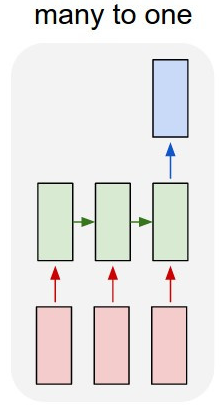    

## **Preprocessing for natural language processing (NLP)**






- To put words in a sentence as input to neural network, we should preprocess the text data and convert the words in a sentence to a vector representation.

- The process for this is as follows (refer to the figures below):
    - **Step 1. Text preprocessing**
        - 1) Tokenization : Split a sentence into words
        - 2) Lowercase : Make words lowercase
        - 3) Remove punctuation : Remove punctuations (. / , ' ' ~ ?) that are not necessary for analysis
    - **Step 2. Make vocabulary and give each word a unique integer**
        - Collect the words from the training dataset and make a vocabulary book.
        - Give a unique integer to each word in the vocabulary
    - **Step 3. Word embedding**
        - Give each integer a unique vector
        - There are various methods for word embedding. It will be described later.



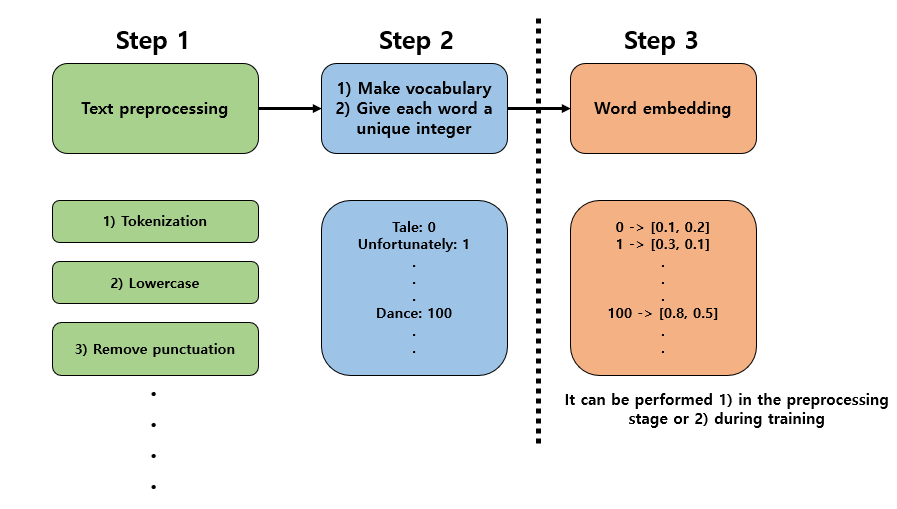

For example, each sentence is converted to corresponding vectors as follows:

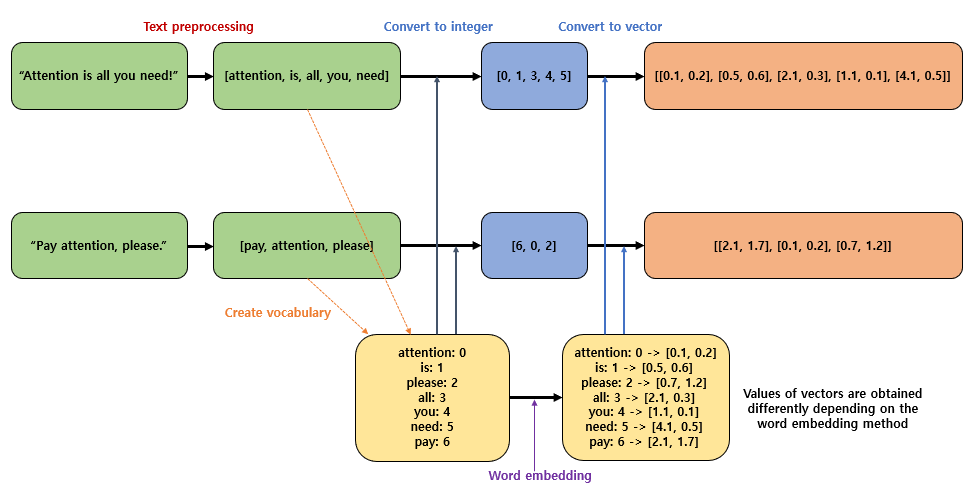

## **1. Preprocessing for natural language processing (NLP) using torchtext**

- PyTorch provides `torchtext package` that can conveniently implement deep learning with text data.


In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
from tqdm import tqdm
import time
import urllib.request
import pandas as pd

#Set random seed for reproduction
random.seed(2023)
np.random.seed(2023)
torch.manual_seed(2023)

!pip install -U torchtext==0.6.0

#torchtext package
from torchtext import data


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 4.4 MB/s eta 0:00:00


### **1) Data loading**

- First, download the `IMDB Movie Review Sentiment Analysis` dataset, which is the dataset we will use for this task.

- Each sample consists of a sentence and a label (0: negative or 1: positive)

In [ ]:
#Data loading

urllib.request.urlretrieve("https://raw.githubusercontent.com/LawrenceDuan/IMDb-Review-Analysis/master/IMDb_Reviews.csv", filename="IMDb_Reviews.csv")
df = pd.read_csv('IMDb_Reviews.csv', encoding='latin1')
df.head()

,review,sentiment
0,My family and I normally do not watch local mo...,1
1,"Believe it or not, this was at one time the wo...",0
2,"After some internet surfing, I found the ""Home...",0
3,One of the most unheralded great works of anim...,1
4,"It was the Sixties, and anyone with long hair ...",0


In [ ]:
#Check the dataset size

print('The total number of samples : {}'.format(len(df)))

The total number of samples : 50000


In [ ]:
#Split the dataset into train and test dataset

train_df = df[:30000]
test_df = df[-20000:]

train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

### **2) Text preprocessing using Field method**

- We can preprocess text data using Field method provided by torchtext (see https://torchtext.readthedocs.io/en/latest/data.html#fields for details). But you don't have to know it in detail.

In [ ]:
# Text preprocessing using Field method

TEXT = data.Field(sequential=True, # Whether the datatype represents sequential data
                  use_vocab=True, # Whether to make a Vocabulary
                  tokenize=str.split, # The function used to tokenize strings using this field into sequential examples
                  lower=True, # Whether to lowercase the text
                  batch_first=True,
                  fix_length=200)   # Note that the length of the sentences are all different.
                                    # If the length of a sentence is longer than 200, the length is reduced to 200 (remove the back part). And if it is shorter than 200, the length is made 200 by padding with 0.

LABEL = data.Field(sequential=False,
                   batch_first=False,
                   is_target=True) #

### **3) Loading datasets**

In [ ]:
train_data, test_data = data.TabularDataset.splits(
        path='.', train='train_data.csv', test='test_data.csv', format='csv',
        fields=[('text', TEXT), ('label', LABEL)], skip_header=True)

We can see the result of preprocessing as follows:

In [ ]:
print(vars(train_data[1]))

{'text': ['believe', 'it', 'or', 'not,', 'this', 'was', 'at', 'one', 'time', 'the', 'worst', 'movie', 'i', 'had', 'ever', 'seen.', 'since', 'that', 'time,', 'i', 'have', 'seen', 'many', 'more', 'movies', 'that', 'are', 'worse', '(how', 'is', 'it', 'possible??)', 'therefore,', 'to', 'be', 'fair,', 'i', 'had', 'to', 'give', 'this', 'movie', 'a', '2', 'out', 'of', '10.', 'but', 'it', 'was', 'a', 'tough', 'call.'], 'label': '0'}


### **4) Create vocabulary**
- Create a vocabulary by collecting words from training data.

In [ ]:
TEXT.build_vocab(train_data, min_freq=5) # Create vocabulary # Here, add only words that appear at least "min_freq (5)" times in the trainset to the vocabulary # Words that appear less than five times are replaced with the token <unk> in the sense of Unknown.
LABEL.build_vocab(train_data)

In [ ]:
vocab_size = len(TEXT.vocab)
num_classes = 2
print('The size of vocabulary : {}'.format(vocab_size))
print('The number of classes : {}'.format(num_classes))

The size of vocabulary : 51394
The number of classes : 2


We can see the vocabulary and the unique integers assigned to each word.

In [ ]:
TEXT.vocab.stoi
# torchtest assigns 0 to <unk> token and 1 to <pad> token.
# <unk> is used to represent words that is not in the vocabulary.
# <pad> is used for padding to match the fixed length.

defaultdict(<bound method Vocab._default_unk_index of <torchtext.vocab.Vocab object at 0x7861410b2f60>>,
            {'<unk>': 0,
             '<pad>': 1,
             'the': 2,
             'a': 3,
             'and': 4,
             'of': 5,
             'to': 6,
             'is': 7,
             'in': 8,
             'i': 9,
             'this': 10,
             'it': 11,
             'that': 12,
             '/><br': 13,
             'was': 14,
             'as': 15,
             'with': 16,
             'for': 17,
             'but': 18,
             'on': 19,
             'movie': 20,
             'his': 21,
             'are': 22,
             'not': 23,
             'you': 24,
             'film': 25,
             'have': 26,
             'he': 27,
             'be': 28,
             'at': 29,
             'one': 30,
             'by': 31,
             'an': 32,
             'they': 33,
             'from': 34,
             'who': 35,
             'all': 36,
             'like

### **5) Dataloader**
- TorchText supports batch processing of all data and provides a BucketIterator that replaces words with corresponding integers using the vocabulary created above.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device : {}'.format(device))
batch_size = 64

train_iter, test_iter = data.BucketIterator.splits(
        (train_data, test_data), batch_size=batch_size,
        shuffle=True, repeat=False)

batch = next(iter(train_iter))

Device : cuda


We can see that each word is converted to the corresponding integer value.

The shape of a batch should be [64, 200] = [batch size, fixed_length (sequence length)]

In [ ]:
print(f"Index of <pad> token: {TEXT.vocab.stoi["<pad>"]}")
print("Shape of batch is : ", batch.text.shape)  # torch.Size([64, 200])  batch_size x fix_length
print(batch.text)

Index of <pad> token: 1
Shape of batch is :  torch.Size([64, 200])
tensor([[    9,   176,   251,  ...,     1,     1,     1],
        [    9,   217,     3,  ...,     1,     1,     1],
        [ 2624,     3,  2517,  ...,     2,   637,     4],
        ...,
        [    9,    26,    23,  ...,     9,    53,    37],
        [    9,  5219,    19,  ...,     1,     1,     1],
        [    9,  5983,     8,  ...,   253,     8, 39307]])


Divide the training dataset to get the validation set.



In [ ]:
train_data, val_data = train_data.split(split_ratio=0.8)

train_iter, val_iter, test_iter = data.BucketIterator.splits(
        (train_data, val_data, test_data), batch_size=batch_size,
        shuffle=True, repeat=False, sort=False)

## **2. Word Embedding**


- If we use the one-hot encoding method (sparse representation) for word embedding as in the previous practice session, the curse of dimensionality occurs (note that the vocab size is 51394).
- Therefore, in practice, we have to express a word as a dense vector (distributed representation) with low dimension.
- There are various methods for word embedding in NLP. Among them, we will use nn.Embedding provided by PyTorch for this task.
- nn.Embedding provides a lookup table which stores embeddings of each word.
- Therefore, each integer is converted to a corresponding vector, referring to the lookup table. The values in the lookup table are learnable parameters and are updated at the training time (see the below figure).
- **You don't need to know it in detail. Just understand that it converts each integer to the corresponding vector.**

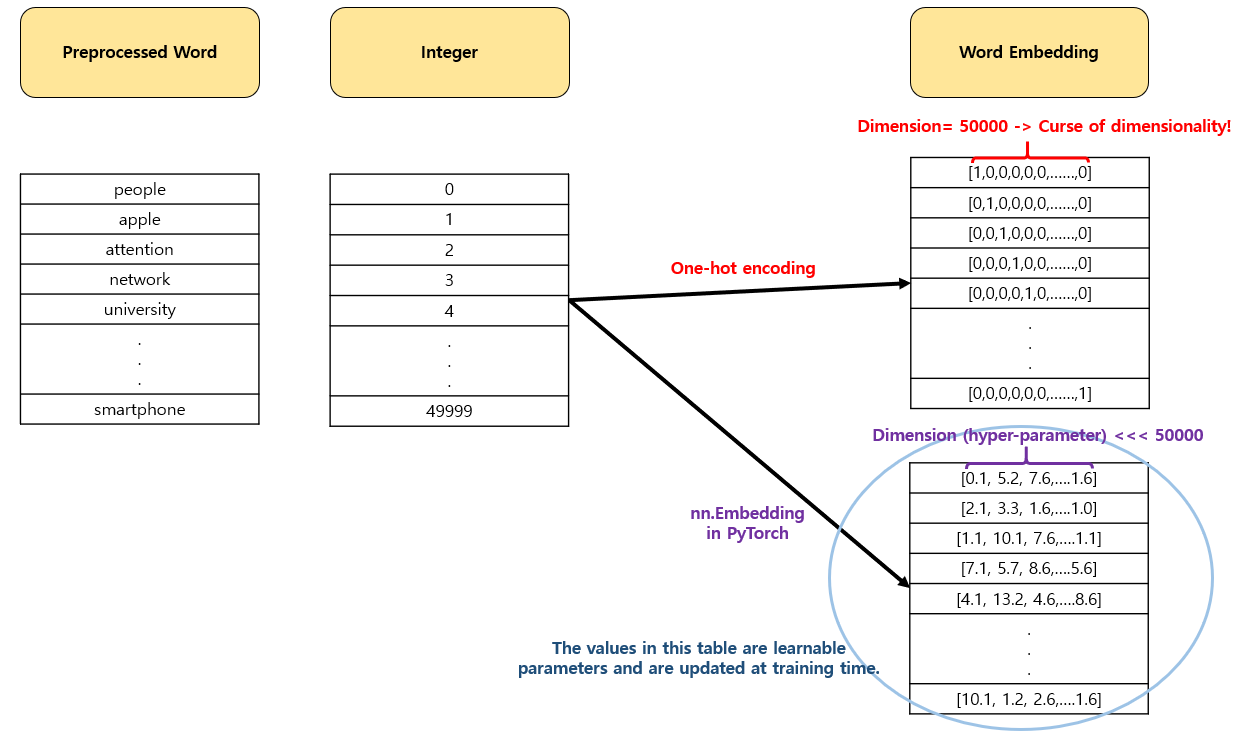

## **Task 1. Implement LSTM network and LSTMCell module**


- Finally, we understood the transformation from sentences to vector representations suitable for the input of neural network.
- Based on these concepts, let's implement LSTM network for our task (IMDB Movie Review Sentiment Analysis).

- First of all, you will implement ```LSTMCell``` which will be used in the ```MyLSTM``` module. (please refer to https://pytorch.org/docs/stable/generated/torch.nn.LSTMCell.html to grasp what parameters and methods are here and how each method works)  

**Hint: You can define the weights of LSTMCell by using either ```nn.Linear()``` or ```nn.Parameter()```.**

- Embedding vectors corresponding to words are sequentially entered into the LSTMCell one by one, and 'h (hidden state)' and 'c (cell state)' are iteratively changed. At the end, you should take only **the last hidden state** and pass it through the dropout layer, and finally use the fc layer to perform classification.

- Note that **batch-wise operation is performed**. It would be good to check the size of each output at each stage. (You will find this easily if you use the `pdb.set_trace()` in the `pdb` module.)

The following figure shows a single LSTM cell:

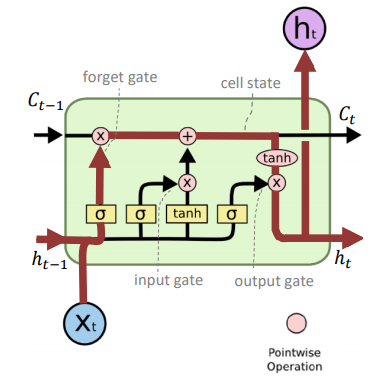

The overall process is well described in the figure below.
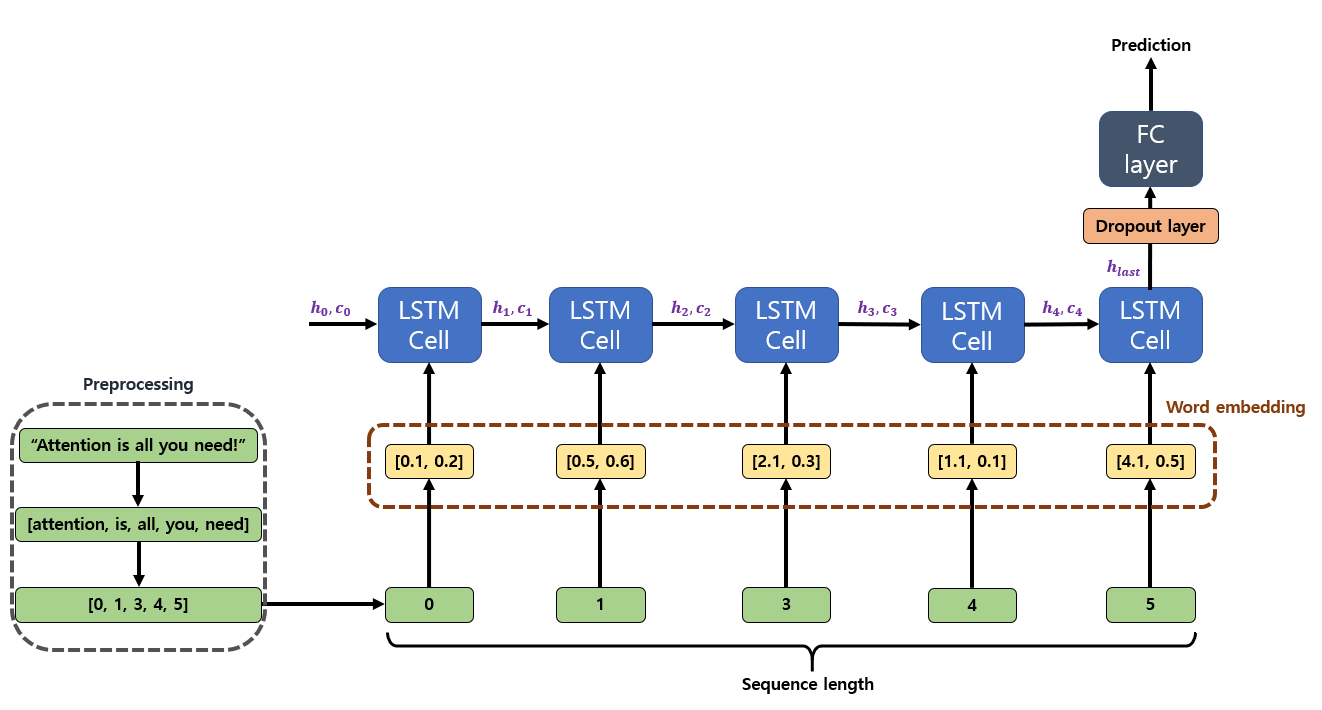

## **TODO** : Fill in the blanks of the codes to perform the above process and write your own description of the source code in your report.

In [ ]:
import math

class MyLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(MyLSTMCell, self).__init__()
        # fill in the blank --------------------------------------
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.weight_ih = nn.Parameter(torch.Tensor(4 * hidden_size, input_size))
        self.weight_hh = nn.Parameter(torch.Tensor(4 * hidden_size, hidden_size))
        self.bias_ih = nn.Parameter(torch.Tensor(4 * hidden_size))
        self.bias_hh = nn.Parameter(torch.Tensor(4 * hidden_size))



        # --------------------------------------------------------
        self.reset_parameters()

    def reset_parameters(self):
        stdv = 1.0 / math.sqrt(self.hidden_size) if self.hidden_size > 0 else 0
        for weight in self.parameters():
            nn.init.uniform_(weight, -stdv, stdv)

    def forward(self, input, hidden_states):
        # fill in the blank --------------------------------------
        h_prev, c_prev = hidden_states

        gates = torch.mm(input, self.weight_ih.t()) + self.bias_ih + \
                torch.mm(h_prev, self.weight_hh.t()) + self.bias_hh

        ingate, forgetgate, cellgate, outgate = gates.chunk(4, 1)

        ingate = torch.sigmoid(ingate)
        forgetgate = torch.sigmoid(forgetgate)
        cellgate = torch.tanh(cellgate)
        outgate = torch.sigmoid(outgate)

        cp = (forgetgate * c_prev) + (ingate * cellgate)
        hp = outgate * torch.tanh(cp)


        # --------------------------------------------------------
        return hp, cp

In [ ]:
# Make an lstm model that performs the above task (refer to the above figure).
# Note that batch-wise operation is performed. So check the shape of output at each stage.

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from tqdm import tqdm

import pdb


class MyLSTM(nn.Module):
    def __init__(self, num_layers, hidden_size, n_vocab, embed_dim, num_classes, device, dropout_p=0.5):
        '''
        num_layers: the number of recurrent layers (Here, we just set this to 1.)
        hidden_size: the number of features in the hidden state
        n_vocab: the size of vocabulary
        embed_dim: the dimension of embedding vectors
        num_classes: the number of classes

        '''
        super(MyLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.device = device
        self.embed = nn.Embedding(n_vocab, embed_dim)      # Define an embedding layer. The shape of lookup table is (n_vocab, embed_dim).
        self.dropout = nn.Dropout(dropout_p)
        self.lstmcell =  MyLSTMCell(embed_dim, self.hidden_size)
        self.out = nn.Linear(self.hidden_size, num_classes)

    def forward(self, x):
        x = self.embed(x) # Word embedding is performed. Therefore the shape of input x becomes (batch_size, sequence_length, embed_dim)
        h, c = self._init_state(batch_size=x.size(0)) # Initialization of hidden and cell state.
        sequence_length = x.shape[1]

        hidden = []

        # fill in the blank --------------------------------------------------------------
        '''
        1) Embedding vectors corresponding to words are sequentially entered into the LSTMCell one by one, and 'h (hidden state)' and 'c (cell state)' are iteratively updated.
        Note that: Store the hidden state of all time steps in the 'hidden' defined as list above and make the 'hidden' (list) into a tensor type using `torch.stack`
        2) Then, you should take only the last hidden state and pass it through the dropout layer, and finally use the fc layer to perform classification.
        '''
        for i in range(sequence_length):
            h, c = self.lstmcell(x[:, i, :], (h, c))
            hidden.append(h)

        last_hidden_state = h

        out = self.out(self.dropout(last_hidden_state))




        # --------------------------------------------------------------------------------

        return out # Shape: (batch size, number of classes)

    def _init_state(self, batch_size=1):
        h = torch.zeros((batch_size, self.hidden_size)).to(self.device)
        c = torch.zeros((batch_size, self.hidden_size)).to(self.device)
        return h, c

#### **Parameter settings for training**

In [ ]:
# Hyper-paramter settings
lr = 0.001
epochs = 5                                                                       # If you increase the number of epochs, you can see the higher performance.
criterion = nn.CrossEntropyLoss(reduction='sum')


#Set random seed for reproduction
random.seed(2026)
np.random.seed(2026)
torch.manual_seed(2026)


# Define model and optimizer
model = MyLSTM(1, 256, vocab_size, 128, num_classes, device, 0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#### **Training and evaluation functions**

In [ ]:
def train(model, optimizer, train_iter, device, Criterion):
    """train model"""
    model.train()
    for b, batch in enumerate(train_iter):
        x, y = batch.text.to(device), batch.label.to(device)
        y.data.sub_(1)
        optimizer.zero_grad()
        output = model(x)
        loss = Criterion(output, y)
        loss.backward()
        optimizer.step()


def evaluate(model, val_iter, device, Criterion):
    """evaluate model"""
    model.eval()
    corrects, total_loss = 0, 0
    for batch in val_iter:
        x, y = batch.text.to(device), batch.label.to(device)
        y.data.sub_(1)
        output = model(x)
        loss = Criterion(output, y)
        total_loss += loss.item()
        corrects += (output.max(1)[1].view(y.size()).data == y.data).sum()


    size = len(val_iter.dataset)
    loss_avg = total_loss / size
    acc_avg = 100.0 * corrects / size
    return loss_avg, acc_avg

## **Training and Evaulation**

In [ ]:
#Model training
best_val_loss = None

for e in tqdm(range(1, epochs+1)):
    train(model, optimizer, train_iter, device, criterion )
    val_loss, val_accuracy = evaluate(model, val_iter, device, criterion)

    print("[Epoch: %d] val accuracy : %5.2f" % (e, val_accuracy))

    # Save best model
    if not best_val_loss or val_loss < best_val_loss:
        if not os.path.isdir("best_lstm_model"):
            os.makedirs("best_lstm_model")
        torch.save(model.state_dict(), './best_lstm_model/best_model.pt')
        best_val_loss = val_loss

 20%|██        | 1/5 [01:06<04:27, 66.86s/it]

[Epoch: 1] val accuracy : 50.17


 40%|████      | 2/5 [02:12<03:18, 66.15s/it]

[Epoch: 2] val accuracy : 54.47


 60%|██████    | 3/5 [03:18<02:12, 66.15s/it]

[Epoch: 3] val accuracy : 72.93


 80%|████████  | 4/5 [04:24<01:05, 65.84s/it]

[Epoch: 4] val accuracy : 71.15


100%|██████████| 5/5 [05:30<00:00, 66.14s/it]

[Epoch: 5] val accuracy : 71.20


In [ ]:
#Model evaluation

model.load_state_dict(torch.load('./best_lstm_model/best_model.pt'))
test_loss, test_acc = evaluate(model, test_iter, device, criterion)
print('test loss: %5.2f | text accuracy: %5.2f' % (test_loss, test_acc))

test loss:  0.60 | text accuracy: 70.78


## **Task 2. Implement LSTM network with attention mechanism**

- In this movie review task, a particular word within a sentence can have a large impact on prediction, so higher performance can be expected if we add the **attention mechanism**, an algorithm that focuses more on the important parts for prediction.

- To apply the attention mechanism to the above network, the following processes are added:

    - Step 1. The last hidden state is given as a query, and based on this, the similarities with the hidden states in the previous step are measured using dot-product.
    - Step 2. Using a softmax function, the results are normalized and attention scores (α) for each hidden state are obtained.
    - Step 3. Based on the attention scores (α) of each hidden state, we take a weighted average of hidden states (except for the last) and then, obtain a context vector,
$h_{context}$.
    - Step 4. The context vector is concatenated with the last hidden state and prediction is performed based on it.

The overall process is well described in the figure below.

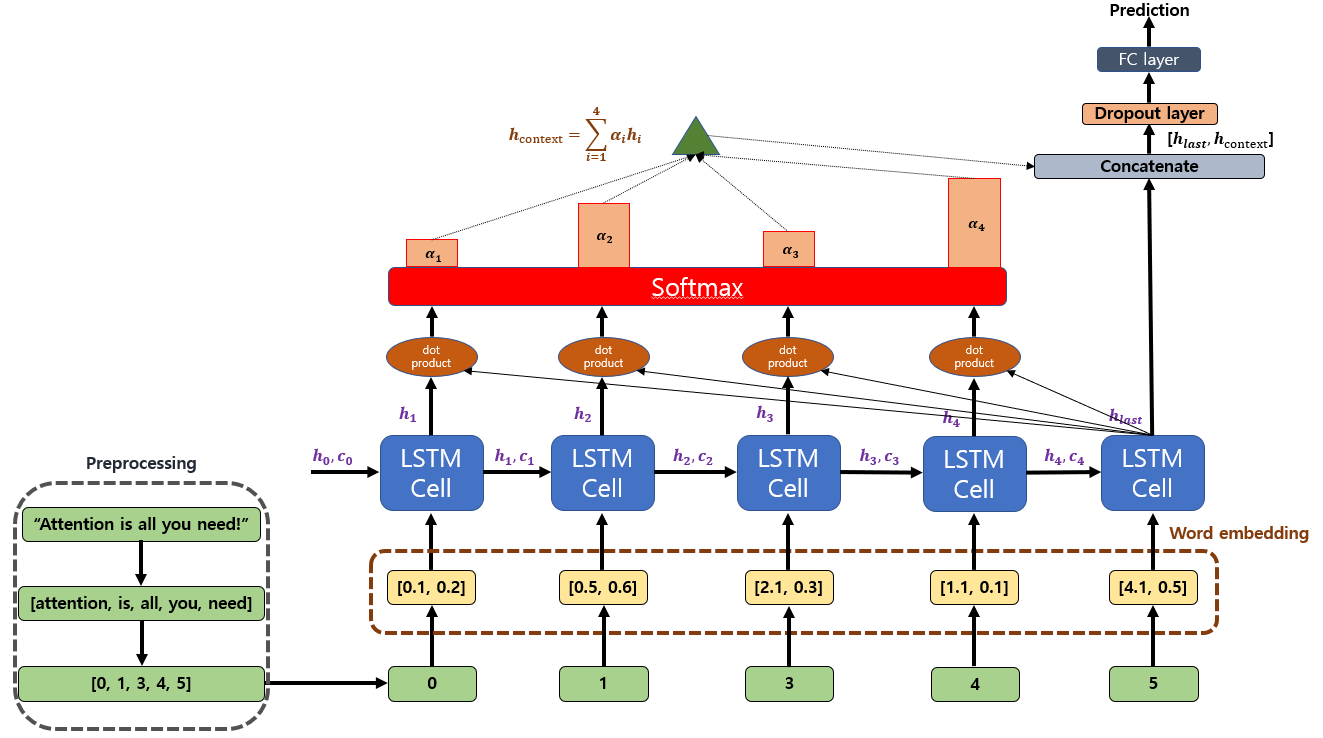

## **TODO** : Fill in the blanks of the codes to perform the above process.

In [ ]:
# Make an lstm model with the attention mechanism that performs the above process.
# Note that batch-wise operation is performed. So check the shape of output at each stage.

# When implementing the attention mechanism, it is recommended to use broadcasting (the for loops may not be used). See https://numpy.org/doc/stable/user/basics.broadcasting.html for the details of broadcasting.
# If necessary, use unsqueeze() or squeeze() function to match the dimension for broadcasting.


import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from tqdm import tqdm

import pdb


class MyLSTM_att(nn.Module):
    def __init__(self, num_layers, hidden_size, n_vocab, embed_dim, num_classes, device, dropout_p=0.5):
        super(MyLSTM_att, self).__init__()


        self.hidden_size = hidden_size
        self.device = device
        self.embed = nn.Embedding(n_vocab, embed_dim)
        self.dropout = nn.Dropout(dropout_p)
        self.lstmcell =  MyLSTMCell(embed_dim, self.hidden_size)

        # fill in the blank --------------------------------------------------------------
        self.out = nn.Linear(self.hidden_size * 2, num_classes)                                  # This is the FC layer for final prediction in the above figure.
        # --------------------------------------------------------------------------------


    def forward(self, x):
        x = self.embed(x) # shape: (batch_size, sequence_length, embed_dim)
        h, c = self._init_state(batch_size=x.size(0)) # initialization
        hidden = []
        sequence_length = x.shape[1]

        # fill in the blank --------------------------------------------------------------
        '''
        You should add the following attention mechnism to the model in task 1 (refer to the above figure):
        1) The last hidden state is given as a query, and based on this, the similarities with the hidden states in the previous step are measured using dot-product.
        2) Using a softmax function, the results are normalized and attention scores (α) for each hidden state are obtained.
        3) Based on the attention scores (α) of each hidden state, we take a weighted average of hidden states (except for the last) and then, obtain a context vector.
        4) The context vector is concatenated with the last hidden state and prediction is performed based on it.
        '''
        for i in range(sequence_length):
            h, c = self.lstmcell(x[:, i, :], (h, c))
            hidden.append(h)

        # Convert list of hidden states to a tensor
        # hidden: (sequence_length, batch_size, hidden_size)
        hidden_states_tensor = torch.stack(hidden)

        # Permute to (batch_size, sequence_length, hidden_size)
        hidden_states_tensor = hidden_states_tensor.permute(1, 0, 2)

        # Last hidden state (query)
        # h_last: (batch_size, hidden_size)
        h_last = h

        # Calculate similarities (dot product)
        # h_last_unsqueeze: (batch_size, 1, hidden_size)
        # scores: (batch_size, sequence_length)
        scores = torch.bmm(hidden_states_tensor, h_last.unsqueeze(2)).squeeze(2)

        # Apply softmax to get attention scores (alpha)
        # alpha: (batch_size, sequence_length)
        alpha = F.softmax(scores, dim=1)

        # Calculate context vector (weighted average of hidden states)
        # alpha_unsqueeze: (batch_size, sequence_length, 1)
        # context_vector: (batch_size, hidden_size)
        context_vector = torch.bmm(alpha.unsqueeze(1), hidden_states_tensor).squeeze(1)

        # Concatenate context vector with the last hidden state
        # combined_vector: (batch_size, hidden_size * 2)
        combined_vector = torch.cat((context_vector, h_last), dim=1)

        # Pass through dropout and FC layer
        out = self.out(self.dropout(combined_vector))

        # --------------------------------------------------------------------------------

        return out

    def _init_state(self, batch_size=1):
        h = torch.zeros((batch_size, self.hidden_size)).to(self.device)
        c = torch.zeros((batch_size, self.hidden_size)).to(self.device)
        return h, c

#### **Parameter settings for training**

In [ ]:
lr = 0.001
epochs = 5  # If you increase the number of epochs, you can see the higher performance.
criterion = nn.CrossEntropyLoss(reduction='sum')

#Set random seed for reproduction
random.seed(2023)
np.random.seed(2023)
torch.manual_seed(2023)

model = MyLSTM_att(1, 256, vocab_size, 128, num_classes, device, 0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

## **Training and Evaulation**

In [ ]:
#Model training
best_val_loss = None



for e in tqdm(range(1, epochs+1)):
    train(model, optimizer, train_iter, device, criterion )
    val_loss, val_accuracy = evaluate(model, val_iter, device, criterion)

    print("[Epoch: %d] val accuracy : %5.2f" % (e, val_accuracy))

    if not best_val_loss or val_loss < best_val_loss:
        if not os.path.isdir("best_lstm_model_with_attention"):
            os.makedirs("best_lstm_model_with_attention")
        torch.save(model.state_dict(), './best_lstm_model_with_attention/best_model.pt')
        best_val_loss = val_loss

 20%|██        | 1/5 [01:06<04:27, 66.94s/it]

[Epoch: 1] val accuracy : 53.10


 40%|████      | 2/5 [02:13<03:19, 66.57s/it]

[Epoch: 2] val accuracy : 77.68


 60%|██████    | 3/5 [03:20<02:13, 66.71s/it]

[Epoch: 3] val accuracy : 81.35


 80%|████████  | 4/5 [04:27<01:06, 66.79s/it]

[Epoch: 4] val accuracy : 84.75


100%|██████████| 5/5 [05:33<00:00, 66.64s/it]

[Epoch: 5] val accuracy : 84.92


In [ ]:
#Model evaluation
model.load_state_dict(torch.load('./best_lstm_model_with_attention/best_model.pt'))
test_loss, test_acc = evaluate(model, test_iter, device, criterion)
print('test loss: %5.2f | text accuracy: %5.2f' % (test_loss, test_acc))

test loss:  0.37 | text accuracy: 84.95


## **Check the result with a test sample**

In [ ]:
import numpy as np

# Bring a sample from test dataset
test_example = vars(test_data[16])
print('Test example: ', test_example['text'])

Test example:  ['the', 'movie', 'is', 'okay.', 'meaning', 'that', 'i', "don't", 'regret', 'watching', 'it!', 'i', 'found', 'the', 'acting', 'purely', 'and', 'the', 'most', 'of', 'the', 'dialog', 'stupid', '("oh', 'no,', 'this', 'was', 'my', 'grandmothers', 'bible!").', "it's", 'sort', 'of', 'bad', 'remake', 'of', 'u-turn.', 'a', 'man', 'arrives', 'to', 'a', 'desert', 'town', 'out', 'in', 'nowhere,', 'meets', 'the', 'wrong', 'people', 'and', 'falls', 'in', 'love', 'with', 'the', 'wrong', 'woman.', 'and', 'off', 'cause', "get's", 'involved', 'in', 'something,', 'he', 'thought', 'he', 'could', 'leave', 'behind', 'him.', 'the', 'movie', 'is', 'quite', 'predictable', 'and', 'there', 'is', 'really', 'nothing', 'new', 'in', 'it.', 'when', "it's", 'finish,', 'you', "didn't", 'really', 'care.', 'most', 'of', 'the', 'characters', 'are', 'stereotypes,', 'specially', 'brian', 'austin', 'green!!', 'all', 'in', 'all', 'just', 'another', 'movie', 'from', 'the', 'states,', 'but', 'okay', 'entertaining

In [ ]:
# Check the result with a test sample using our trained model

index_vector = []

for text in test_example['text']:
    index_vector.append(TEXT.vocab.stoi[text])

index_vector_numpy = np.array(index_vector)
index_vector_tensor = torch.from_numpy(index_vector_numpy)
index_vector_tensor = index_vector_tensor.view(1,index_vector_tensor.size(0))

prediction = model(index_vector_tensor.to(device)).max(1)[1].item() # make a prediction through our trained model
prediction = 'Positive review' if prediction==1 else 'Negative review'
Ground_truth = 'Positive review' if test_example['label']==1 else 'Negative review'

# Compare the result with groundtruth
print('The prediction of our trained model on the test example:', prediction)
print('The true label of the test example:', Ground_truth)

The prediction of our trained model on the test example: Negative review
The true label of the test example: Negative review


## **TODO** : Describe the advantages of using the attention mechanism in the above task.

### Advantages of using the attention mechanism in sentiment analysis:

The attention mechanism significantly enhances the performance and interpretability of models like LSTM for tasks such as movie review sentiment analysis.

1.  **Focus on Salient Information**: Movie reviews can be lengthy, and not all words contribute equally to the sentiment. The attention mechanism allows the model to dynamically weigh the importance of different words or parts of the input sequence. For example, in a review, positive sentiment might strongly depend on words like "fantastic" or "brilliant," while negative sentiment might hinge on words like "terrible" or "boring." Attention helps the model identify and focus on these critical terms, even if they appear far from the end of the sentence.

2.  **Improved Performance**: By allowing the model to concentrate on the most relevant parts of the input, attention often leads to higher accuracy in classification tasks. It effectively mitigates the issue of information loss over long sequences, which can be a problem for traditional RNNs where the influence of early words might diminish by the time the model processes later words.

3.  **Interpretability**: One of the significant advantages of attention is that it provides a degree of interpretability. The attention scores (α) indicate which parts of the input sequence were most influential in the model's decision-making process. For instance, you could visualize these scores to highlight the words that the model paid the most attention to when classifying a review as positive or negative. This helps in understanding *why* the model made a particular prediction.

4.  **Handling Long-Range Dependencies**: In long movie reviews, a word at the beginning of the sentence might be crucial for understanding the sentiment expressed at the end. Attention mechanisms can establish direct connections between distant words and the current context, making it easier to capture and utilize long-range dependencies that might be hard for standard LSTMs to retain across many time steps.

5.  **Enhanced Contextual Understanding**: By creating a context vector from a weighted sum of all hidden states, the attention mechanism provides a richer and more relevant summary of the entire input sequence for the final prediction step. This context is tailored specifically to the query (the last hidden state), allowing for a more nuanced understanding of the input.

In summary, for tasks like sentiment analysis, where specific keywords or phrases heavily influence the overall meaning, the attention mechanism provides a powerful way to improve model accuracy, robustness, and transparency.

---------------------------------------------------------

#**Reference**

(1) Part1: Implement LSTM model in word-level language modelling

https://towardsdatascience.com/nlp-preprocessing-with-nltk-3c04ee00edc0

https://wikidocs.net/60314

https://zzsza.github.io/data/2018/03/10/nlp-python/

https://i.stack.imgur.com/GmKNd.png

https://www.gousios.gr/courses/ml4se/2019/nn.html

https://torchtext.readthedocs.io/en/latest/data.html#fields